DC OPF_IEEE 9-bus system

In [62]:
#import libraries

from pandapower.create import (
    create_gen,
    create_load,
    create_poly_cost
)

from pandapower.run import runopp, rundcopp
from pandapower import from_pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
#from pandapower.runpm import runpm_ac_opf, runpm_dc_opf

In [63]:
#load IEEE 9-bus system
def load_network():
    return from_pickle("ieee9bus.p")

In [64]:
#plot results

def opf_results(results):
    %matplotlib inline
    plt.rc('xtick', labelsize=9)
    plt.rc('ytick', labelsize=9)
    plt.rc('legend', fontsize=9)
    plt.rc('axes', labelsize=10)
    plt.rcParams['font.size'] = 10

    sns.set_style("whitegrid", {'axes.grid' : False})
    fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,5))
    ax = axes
    sns.boxplot(results.installed_mw, width=.1, ax=ax, orient="v")
    ax.set_ylabel("Installed Active Power [MW]")

In [65]:
def dcopf_gen():
    results = pd.DataFrame(columns=["installed_mw"])
    iterations = 6

    for i in range(iterations):
        #load new network
        net = load_network()

        #add new generator at bus i
        new_gen = create_gen(net, name="New Gen", bus=net.load.bus.values[i], p_mw=0, min_p_mw=0, max_p_mw=80, min_q_mvar=-60, max_q_mvar=60, vm_pu=1.025, controllable=True)

        #define cost function
        costeg = create_poly_cost(net, element=0, et='ext_grid', cp1_eur_per_mw=1)

        #run DC OPF
        rundcopp(net, verbose=False, delta=1e-16)

        print("Results for hosting capacity for new generation at bus " + str(net.load.bus.values[i]))

        #print ext_grid power
        for j in range(len(net.res_ext_grid)):
            print("Grid Power: " + str(round(net.res_ext_grid.p_mw[j],2)))

        #print generator power
        for j in range(len(net.res_gen)):
            print(net.gen.name[j] + " power = " + str(round(net.res_gen.p_mw[j],2)) + " MW")

        #print line loading
        for j in range(len(net.res_line)):
            print(net.line.name[j] + " loading = " + str(round(net.res_line.loading_percent[j],2)) + "%")

        #print trafo loading
        for j in range(len(net.res_trafo)):
            print(net.trafo.name[j] + " loading = " + str(round(net.res_trafo.loading_percent[j],2)) + "%")

        print("-----------------------------------------------------------------------------------")
        results.loc[i] = round(net.res_gen.p_mw[2],2)
    
    return results

In [66]:
def dcopf_load():
    results = pd.DataFrame(columns=["installed_mw"])
    iterations = 6

    for i in range(iterations):
        #load new network
        net = load_network()

        #add new generator at bus i
        new_load = create_load(net, name="New Load", bus=net.load.bus.values[i], p_mw=0, q_mvar=0, max_p_mw=200, min_p_mw=0, max_q_mvar=150, min_q_mvar=-150, in_service=True, type='wye', controllable=True)

        #define cost function
        costload = create_poly_cost(net, element=6, et='load', cp1_eur_per_mw=-1)

        #run DC OPF
        rundcopp(net, verbose=False, delta=1e-16)

        print("Results for hosting capacity for new load at bus " + str(net.load.bus.values[i]))

        #print new load
        print("New load at bus " + str(net.load.bus.values[i]) + " = " + str(round(net.res_load.p_mw[6],2)) + " MW")

        #print ext_grid power
        for j in range(len(net.res_ext_grid)):
            print("Grid Power: " + str(round(net.res_ext_grid.p_mw[j],2)))

        #print generator power
        for j in range(len(net.res_gen)):
            print(net.gen.name[j] + " power = " + str(round(net.res_gen.p_mw[j],2)) + " MW")

        #print line loading
        for j in range(len(net.res_line)):
            print(net.line.name[j] + " loading = " + str(round(net.res_line.loading_percent[j],2)) + "%")

        #print trafo loading
        for j in range(len(net.res_trafo)):
            print(net.trafo.name[j] + " loading = " + str(round(net.res_trafo.loading_percent[j],2)) + "%")

        print("----------------------------------------------------------------------------------")
        results.loc[i] = round(net.res_load.p_mw[6],2)
    
    return results

Hosting Capacity of Generation

In [67]:
#running dc opf of generation
dcopf_gen_results = dcopf_gen()

Results for hosting capacity for new generation at bus 4
Grid Power: 0.0
Gen 2 power = 149.57 MW
Gen 3 power = 94.91 MW
New Gen power = 70.52 MW
Line4-5 loading = 10.74%
Line4-6 loading = 6.96%
Line5-7 loading = 20.64%
Line6-9 loading = 15.63%
Line7-8 loading = 16.91%
Line8-9 loading = 8.19%
Trafo 1 loading = 0.0%
Trafo 2 loading = 74.79%
Trafo 3 loading = 63.27%
-----------------------------------------------------------------------------------
Results for hosting capacity for new generation at bus 5
Grid Power: 0.0
Gen 2 power = 150.16 MW
Gen 3 power = 94.73 MW
New Gen power = 70.1 MW
Line4-5 loading = 4.74%
Line4-6 loading = 4.74%
Line5-7 loading = 18.52%
Line6-9 loading = 17.86%
Line7-8 loading = 19.18%
Line8-9 loading = 5.92%
Trafo 1 loading = 0.0%
Trafo 2 loading = 75.08%
Trafo 3 loading = 63.15%
-----------------------------------------------------------------------------------
Results for hosting capacity for new generation at bus 6
Grid Power: 0.0
Gen 2 power = 149.83 MW
Gen 3

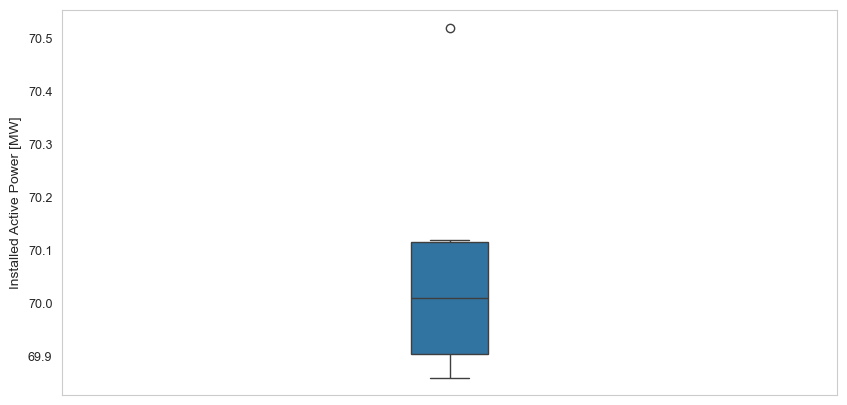

In [68]:
opf_results(dcopf_gen_results)

Hosting Capacity of Consumption

In [69]:
#run dc opf of consumption
dcopf_load_results = dcopf_load()

Results for hosting capacity for new load at bus 4
New load at bus 4 = 200.0 MW
Grid Power: 245.37
Gen 2 power = 161.81 MW
Gen 3 power = 107.82 MW
Line4-5 loading = 7.53%
Line4-6 loading = 3.86%
Line5-7 loading = 23.84%
Line6-9 loading = 18.74%
Line7-8 loading = 16.77%
Line8-9 loading = 8.33%
Trafo 1 loading = 98.15%
Trafo 2 loading = 80.9%
Trafo 3 loading = 71.88%
----------------------------------------------------------------------------------
Results for hosting capacity for new load at bus 5
New load at bus 5 = 200.0 MW
Grid Power: 245.26
Gen 2 power = 161.87 MW
Gen 3 power = 107.87 MW
Line4-5 loading = 51.46%
Line4-6 loading = 10.11%
Line5-7 loading = 30.13%
Line6-9 loading = 12.48%
Line7-8 loading = 10.51%
Line8-9 loading = 14.6%
Trafo 1 loading = 98.1%
Trafo 2 loading = 80.93%
Trafo 3 loading = 71.92%
----------------------------------------------------------------------------------
Results for hosting capacity for new load at bus 6
New load at bus 6 = 200.0 MW
Grid Power: 245.

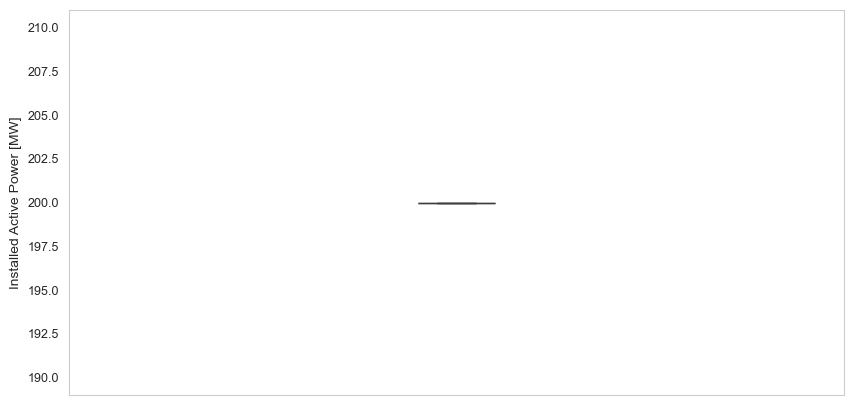

In [70]:
opf_results(dcopf_load_results)